In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
df = pd.read_excel("epl_final.xlsx")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9380 entries, 0 to 9379
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Season             9380 non-null   str  
 1   MatchDate          9380 non-null   int64
 2   HomeTeam           9380 non-null   str  
 3   AwayTeam           9380 non-null   str  
 4   FullTimeHomeGoals  9380 non-null   int64
 5   FullTimeAwayGoals  9380 non-null   int64
 6   FullTimeResult     9380 non-null   str  
 7   HalfTimeHomeGoals  9380 non-null   int64
 8   HalfTimeAwayGoals  9380 non-null   int64
 9   HalfTimeResult     9380 non-null   str  
 10  HomeShots          9380 non-null   int64
 11  AwayShots          9380 non-null   int64
 12  HomeShotsOnTarget  9380 non-null   int64
 13  AwayShotsOnTarget  9380 non-null   int64
 14  HomeCorners        9380 non-null   int64
 15  AwayCorners        9380 non-null   int64
 16  HomeFouls          9380 non-null   int64
 17  AwayFouls          9380 n

In [21]:
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

Dataset shape: (9380, 22)
Columns: ['Season', 'MatchDate', 'HomeTeam', 'AwayTeam', 'FullTimeHomeGoals', 'FullTimeAwayGoals', 'FullTimeResult', 'HalfTimeHomeGoals', 'HalfTimeAwayGoals', 'HalfTimeResult', 'HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners', 'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards', 'HomeRedCards', 'AwayRedCards']

Data types:
Season                 str
MatchDate            int64
HomeTeam               str
AwayTeam               str
FullTimeHomeGoals    int64
FullTimeAwayGoals    int64
FullTimeResult         str
HalfTimeHomeGoals    int64
HalfTimeAwayGoals    int64
HalfTimeResult         str
HomeShots            int64
AwayShots            int64
HomeShotsOnTarget    int64
AwayShotsOnTarget    int64
HomeCorners          int64
AwayCorners          int64
HomeFouls            int64
AwayFouls            int64
HomeYellowCards      int64
AwayYellowCards      int64
HomeRedCards         int64
AwayRedCards         in

In [7]:
print("\nFirst rows:")
display(df.head())


First rows:


,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,36757,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,36757,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,36757,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,36757,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,36757,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0


In [8]:
print("\nSummary statistics:")
display(df.describe(include='all').transpose())


Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Season,9380,25,2000/01,380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MatchDate,9380.0,NaN,NaN,NaN,41291.545522,2627.433642,36757.0,39056.75,41293.0,43526.0,45782.0
HomeTeam,9380,46,Everton,471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AwayTeam,9380,46,Liverpool,471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FullTimeHomeGoals,9380.0,NaN,NaN,NaN,1.535394,1.305432,0.0,1.0,1.0,2.0,9.0
FullTimeAwayGoals,9380.0,NaN,NaN,NaN,1.182623,1.157414,0.0,0.0,1.0,2.0,9.0
FullTimeResult,9380,3,H,4299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HalfTimeHomeGoals,9380.0,NaN,NaN,NaN,0.688273,0.835079,0.0,0.0,0.0,1.0,5.0
HalfTimeAwayGoals,9380.0,NaN,NaN,NaN,0.518763,0.735357,0.0,0.0,0.0,1.0,5.0
HalfTimeResult,9380,3,D,3840,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Numeric columns: ['MatchDate', 'FullTimeHomeGoals', 'FullTimeAwayGoals', 'HalfTimeHomeGoals', 'HalfTimeAwayGoals', 'HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners', 'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards', 'HomeRedCards', 'AwayRedCards']


,MatchDate,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
MatchDate,1.000000,0.022293,0.075839,0.019122,0.059910,0.092803,0.170205,-0.244778,-0.144406,-0.080678,-0.012858,-0.216669,-0.245837,0.128265,0.035455,-0.025514,-0.055764
FullTimeHomeGoals,0.022293,1.000000,-0.085113,0.686053,-0.044342,0.293860,-0.141545,0.437995,-0.112793,0.040268,-0.080432,-0.076328,-0.031932,-0.114536,0.010422,-0.080875,0.078720
FullTimeAwayGoals,0.075839,-0.085113,1.000000,-0.060012,0.685161,-0.128775,0.325767,-0.127921,0.456898,-0.077355,0.045762,-0.001581,-0.045720,0.104072,-0.031703,0.119318,-0.071776
HalfTimeHomeGoals,0.019122,0.686053,-0.060012,1.000000,-0.049855,0.120792,-0.036827,0.259792,-0.050587,-0.046799,0.005448,-0.022368,-0.020992,-0.079742,0.005853,-0.031427,0.030527
HalfTimeAwayGoals,0.059910,-0.044342,0.685161,-0.049855,1.000000,-0.047903,0.174038,-0.075260,0.292954,-0.017530,-0.024250,-0.016340,-0.010891,0.086376,-0.020702,0.072149,-0.027986
HomeShots,0.092803,0.293860,-0.128775,0.120792,-0.047903,1.000000,-0.336635,0.668351,-0.243231,0.483638,-0.296517,-0.151820,-0.033168,-0.105715,0.041252,-0.112555,0.096789
AwayShots,0.170205,-0.141545,0.325767,-0.036827,0.174038,-0.336635,1.000000,-0.263870,0.677796,-0.318202,0.481029,0.014430,-0.127033,0.122752,-0.073290,0.112691,-0.110352
HomeShotsOnTarget,-0.244778,0.437995,-0.127921,0.259792,-0.075260,0.668351,-0.263870,1.000000,-0.045322,0.356250,-0.170833,-0.054081,0.029482,-0.142065,0.011868,-0.074763,0.091576
AwayShotsOnTarget,-0.144406,-0.112793,0.456898,-0.050587,0.292954,-0.243231,0.677796,-0.045322,1.000000,-0.175620,0.345213,0.061108,-0.042496,0.056695,-0.060402,0.107098,-0.071342
HomeCorners,-0.080678,0.040268,-0.077355,-0.046799,-0.017530,0.483638,-0.318202,0.356250,-0.175620,1.000000,-0.254734,-0.079328,0.009185,-0.062937,0.041592,-0.065598,0.054189


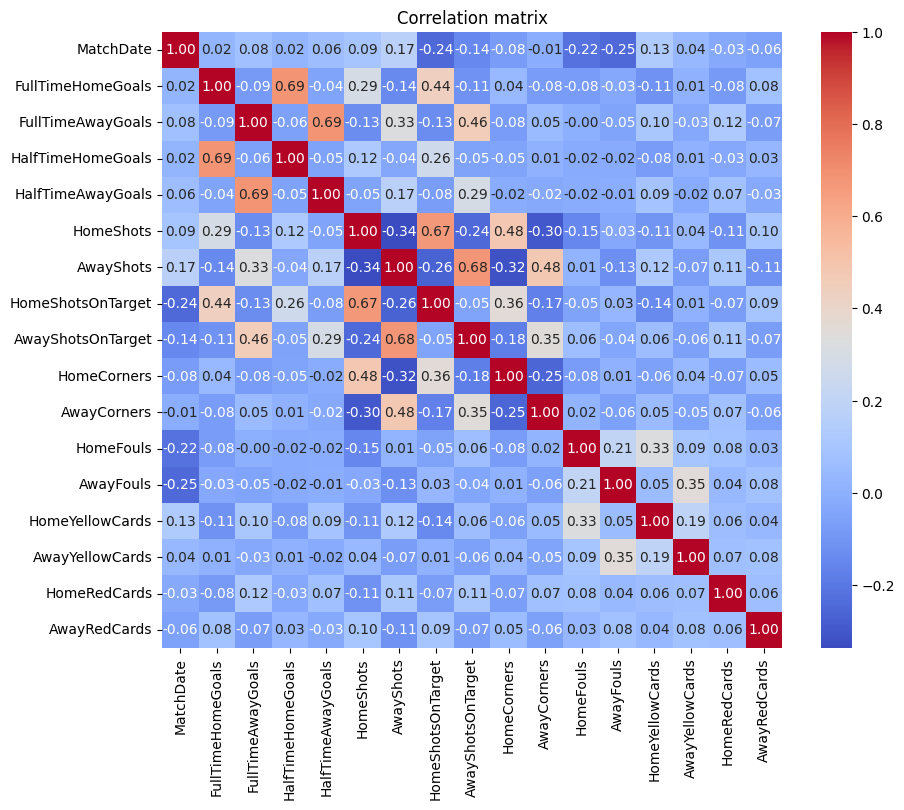

In [9]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
if numeric_cols:
    print("\nNumeric columns:", numeric_cols)
    corr = df[numeric_cols].corr()
    display(corr)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation matrix")
    plt.show()
else:
    print("No numeric columns found for correlation analysis.")


In [10]:
# Check for class balance
# First, identify potential target variables (categorical columns with reasonable number of classes)
print("\n" + "="*60)
print("CHECKING DATASET BALANCE")
print("="*60)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns: {categorical_cols}")

# Check value counts for each categorical column
for col in categorical_cols:
    print(f"\n--- {col} ---")
    value_counts = df[col].value_counts()
    print(f"Number of classes: {len(value_counts)}")
    print(f"Distribution:\n{value_counts}")
    print(f"Percentages:\n{(value_counts/len(df)*100).round(2)}")



CHECKING DATASET BALANCE

Categorical columns: ['Season', 'HomeTeam', 'AwayTeam', 'FullTimeResult', 'HalfTimeResult']

--- Season ---
Number of classes: 25
Distribution:
Season
2000/01    380
2001/02    380
2002/03    380
2005/06    380
2006/07    380
2007/08    380
2008/09    380
2009/10    380
2010/11    380
2011/12    380
2012/13    380
2013/14    380
2014/15    380
2015/16    380
2016/17    380
2017/18    380
2018/19    380
2019/20    380
2020/21    380
2021/22    380
2022/23    380
2023/24    380
2024/25    350
2003/04    335
2004/05    335
Name: count, dtype: int64
Percentages:
Season
2000/01    4.05
2001/02    4.05
2002/03    4.05
2005/06    4.05
2006/07    4.05
2007/08    4.05
2008/09    4.05
2009/10    4.05
2010/11    4.05
2011/12    4.05
2012/13    4.05
2013/14    4.05
2014/15    4.05
2015/16    4.05
2016/17    4.05
2017/18    4.05
2018/19    4.05
2019/20    4.05
2020/21    4.05
2021/22    4.05
2022/23    4.05
2023/24    4.05
2024/25    3.73
2003/04    3.57
2004/05    3.57
N

C:\Users\Ahmed Tarek\AppData\Local\Temp\ipykernel_31084\4042924053.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [11]:
# Calculate balance metrics
print("\n" + "="*60)
print("BALANCE METRICS")
print("="*60)

for col in categorical_cols:
    value_counts = df[col].value_counts()
    total = len(df)
    
    # Calculate imbalance ratio
    max_class_count = value_counts.max()
    min_class_count = value_counts.min()
    imbalance_ratio = max_class_count / min_class_count
    
    # Check for dominant class
    dominant_class_percentage = (max_class_count / total) * 100
    
    print(f"\n{col}:")
    print(f"  Imbalance Ratio: {imbalance_ratio:.2f}:1")
    print(f"  Dominant Class: {dominant_class_percentage:.2f}%")
    print(f"  Balance Status: ", end="")
    
    if imbalance_ratio < 1.5:
        print("✓ WELL BALANCED")
    elif imbalance_ratio < 3:
        print("⚠ MODERATELY IMBALANCED")
    else:
        print("✗ HIGHLY IMBALANCED")



BALANCE METRICS

Season:
  Imbalance Ratio: 1.13:1
  Dominant Class: 4.05%
  Balance Status: ✓ WELL BALANCED

HomeTeam:
  Imbalance Ratio: 24.79:1
  Dominant Class: 5.02%
  Balance Status: ✗ HIGHLY IMBALANCED

AwayTeam:
  Imbalance Ratio: 24.79:1
  Dominant Class: 5.02%
  Balance Status: ✗ HIGHLY IMBALANCED

FullTimeResult:
  Imbalance Ratio: 1.86:1
  Dominant Class: 45.83%
  Balance Status: ⚠ MODERATELY IMBALANCED

HalfTimeResult:
  Imbalance Ratio: 1.71:1
  Dominant Class: 40.94%
  Balance Status: ⚠ MODERATELY IMBALANCED


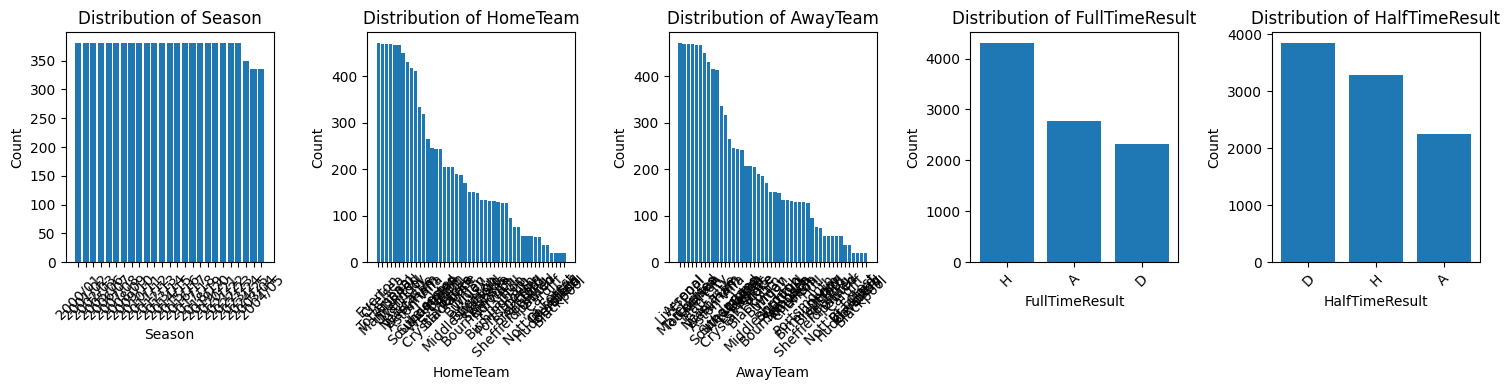

In [12]:
# Visualize class distributions
if categorical_cols:
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15, 4))
    if len(categorical_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(categorical_cols):
        value_counts = df[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45)
    
    plt.tight_layout()
    plt.show()



HOME GOALS vs AWAY GOALS ANALYSIS

✓ Found columns: Home Goals = 'HalfTimeHomeGoals', Away Goals = 'HalfTimeAwayGoals'

📊 HOME GOALS Statistics:
   Mean: 0.69
   Median: 0.00
   Std Dev: 0.84
   Min: 0, Max: 5
   Total: 6456

📊 AWAY GOALS Statistics:
   Mean: 0.52
   Median: 0.00
   Std Dev: 0.74
   Min: 0, Max: 5
   Total: 4866

⚖️  COMPARISON:
   Home Goals Mean - Away Goals Mean: 0.1695
   Home Goals Total - Away Goals Total: 1590

   ✗ NOT EQUAL - Home team scores MORE goals on average
     Home advantage: 0.1695 goals per match


C:\Users\Ahmed Tarek\AppData\Local\Temp\ipykernel_31084\4154748615.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([home_goals, away_goals], labels=['Home Goals', 'Away Goals'])


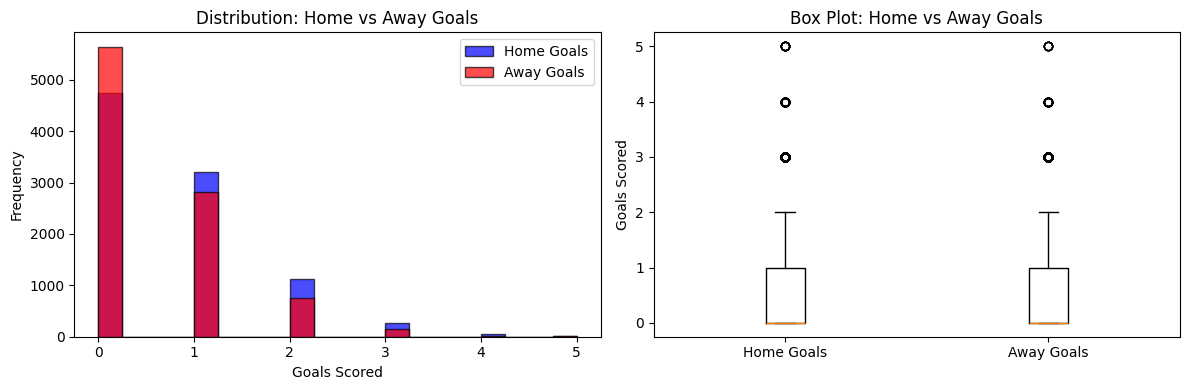

In [14]:
# Compare Home Goals vs Away Goals
print("\n" + "="*80)
print("HOME GOALS vs AWAY GOALS ANALYSIS")
print("="*80)

# Find goal-related columns
home_goal_col = None
away_goal_col = None

for col in df.columns:
    col_lower = col.lower()
    if 'home' in col_lower and ('goal' in col_lower or 'gf' in col_lower):
        home_goal_col = col
    if 'away' in col_lower and ('goal' in col_lower or 'gf' in col_lower):
        away_goal_col = col

if home_goal_col and away_goal_col:
    print(f"\n✓ Found columns: Home Goals = '{home_goal_col}', Away Goals = '{away_goal_col}'")
    
    home_goals = df[home_goal_col]
    away_goals = df[away_goal_col]
    
    print(f"\n📊 HOME GOALS Statistics:")
    print(f"   Mean: {home_goals.mean():.2f}")
    print(f"   Median: {home_goals.median():.2f}")
    print(f"   Std Dev: {home_goals.std():.2f}")
    print(f"   Min: {home_goals.min()}, Max: {home_goals.max()}")
    print(f"   Total: {home_goals.sum()}")
    
    print(f"\n📊 AWAY GOALS Statistics:")
    print(f"   Mean: {away_goals.mean():.2f}")
    print(f"   Median: {away_goals.median():.2f}")
    print(f"   Std Dev: {away_goals.std():.2f}")
    print(f"   Min: {away_goals.min()}, Max: {away_goals.max()}")
    print(f"   Total: {away_goals.sum()}")
    
    print(f"\n⚖️  COMPARISON:")
    mean_diff = home_goals.mean() - away_goals.mean()
    print(f"   Home Goals Mean - Away Goals Mean: {mean_diff:.4f}")
    print(f"   Home Goals Total - Away Goals Total: {home_goals.sum() - away_goals.sum()}")
    
    if abs(mean_diff) < 0.1:
        print(f"\n   ✓ EQUAL - Home and Away goals are BALANCED")
    else:
        print(f"\n   ✗ NOT EQUAL - Home team scores {'MORE' if mean_diff > 0 else 'FEWER'} goals on average")
        print(f"     Home advantage: {mean_diff:.4f} goals per match")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].hist(home_goals, bins=20, alpha=0.7, label='Home Goals', color='blue', edgecolor='black')
    axes[0].hist(away_goals, bins=20, alpha=0.7, label='Away Goals', color='red', edgecolor='black')
    axes[0].set_xlabel('Goals Scored')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution: Home vs Away Goals')
    axes[0].legend()
    
    axes[1].boxplot([home_goals, away_goals], labels=['Home Goals', 'Away Goals'])
    axes[1].set_ylabel('Goals Scored')
    axes[1].set_title('Box Plot: Home vs Away Goals')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"\n✗ Could not find home/away goal columns")
    print(f"Available columns: {list(df.columns)}")



FULL TIME RESULT ANALYSIS

✓ Found column: 'FullTimeHomeGoals'

📊 MATCH RESULTS DISTRIBUTION:
   Total matches: 9380
   1               | Count:  2985 |  31.82% ███████████████
   2               | Count:  2312 |  24.65% ████████████
   0               | Count:  2186 |  23.30% ███████████
   3               | Count:  1161 |  12.38% ██████
   4               | Count:   489 |   5.21% ██
   5               | Count:   166 |   1.77% 
   6               | Count:    55 |   0.59% 
   7               | Count:    17 |   0.18% 
   8               | Count:     6 |   0.06% 
   9               | Count:     3 |   0.03% 

⚖️  BALANCE ANALYSIS:
   Most common: 1 (2985 matches, 31.82%)
   Least common: 9 (3 matches, 0.03%)
   Imbalance ratio: 995.00:1

🎯 VERDICT:
   ✗ IMBALANCED - Significant variation in result frequencies


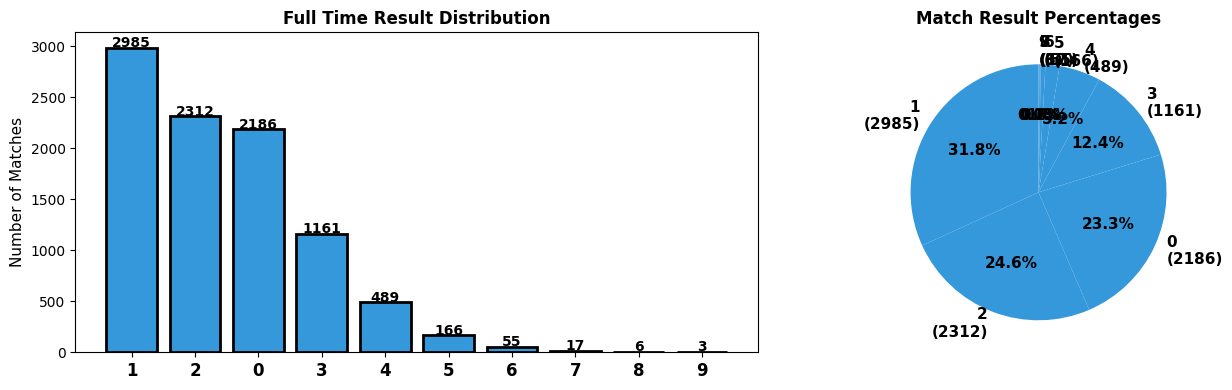

In [20]:
# Analyze Full Time Result Distribution
print("\n" + "="*80)
print("FULL TIME RESULT ANALYSIS")
print("="*80)

# Find FTR column
ftr_col = None
for col in df.columns:
    if 'ftr' in col.lower() or 'result' in col.lower() or ('full' in col.lower() and 'time' in col.lower()):
        ftr_col = col
        break

if ftr_col:
    print(f"\n✓ Found column: '{ftr_col}'")
    
    ftr = df[ftr_col]
    result_counts = ftr.value_counts().sort_values(ascending=False)
    total_matches = len(df)
    
    print(f"\n📊 MATCH RESULTS DISTRIBUTION:")
    print(f"   Total matches: {total_matches}")
    
    for result, count in result_counts.items():
        percentage = (count / total_matches) * 100
        bar_length = int(percentage / 2)
        bar = "█" * bar_length
        print(f"   {str(result):15} | Count: {count:5} | {percentage:6.2f}% {bar}")
    
    print(f"\n⚖️  BALANCE ANALYSIS:")
    max_result = result_counts.max()
    min_result = result_counts.min()
    imbalance_ratio = max_result / min_result if min_result > 0 else float('inf')
    
    print(f"   Most common: {result_counts.index[0]} ({result_counts.iloc[0]} matches, {(result_counts.iloc[0]/total_matches*100):.2f}%)")
    print(f"   Least common: {result_counts.index[-1]} ({result_counts.iloc[-1]} matches, {(result_counts.iloc[-1]/total_matches*100):.2f}%)")
    print(f"   Imbalance ratio: {imbalance_ratio:.2f}:1")
    
    print(f"\n🎯 VERDICT:")
    if imbalance_ratio < 1.3:
        print(f"   ✓ BALANCED - Results are evenly distributed")
    elif imbalance_ratio < 1.8:
        print(f"   ⚠ MODERATELY IMBALANCED - Some results more common than others")
    else:
        print(f"   ✗ IMBALANCED - Significant variation in result frequencies")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Bar plot
    colors = ['#2ecc71' if r == 'H' else '#e74c3c' if r == 'A' else '#3498db' for r in result_counts.index]
    axes[0].bar(range(len(result_counts)), result_counts.values, color=colors, edgecolor='black', linewidth=2)
    axes[0].set_xticks(range(len(result_counts)))
    axes[0].set_xticklabels(result_counts.index, fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Number of Matches', fontsize=11)
    axes[0].set_title('Full Time Result Distribution', fontsize=12, fontweight='bold')
    
    for i, v in enumerate(result_counts.values):
        axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
    
    # Pie chart
    labels = [f'{result}\n({count})' for result, count in result_counts.items()]
    axes[1].pie(result_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', 
                startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    axes[1].set_title('Match Result Percentages', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

else:
    print(f"\n✗ Could not find Full Time Result column")
    print(f"Available columns: {list(df.columns)}")


## Full Time Result Codes Explained

| Code | Meaning | Explanation |
|------|---------|-------------|
| **H** | Home Win | Home team won the match |
| **A** | Away Win | Away team won the match |
| **D** | Draw | Both teams scored the same number of goals (tie) |

### Example:
- If FTR = **H**: Home team 2, Away team 1 ✓ Home Won
- If FTR = **A**: Home team 1, Away team 2 ✓ Away Won  
- If FTR = **D**: Home team 1, Away team 1 ✓ Draw/Tie


In [23]:
# Quick Count Summary
print("\n" + "="*60)
print("MATCH RESULTS COUNT SUMMARY")
print("="*60)

ftr = df['FullTimeResult']
total = len(df)

h_wins = (ftr == 'H').sum()
a_wins = (ftr == 'A').sum()
draws = (ftr == 'D').sum()

print(f"\n📊 TOTAL COUNTS:")
print(f"  🏠 Home Wins (H): {h_wins:,} matches")
print(f"  ✈️  Away Wins (A): {a_wins:,} matches")
print(f"  🤝 Draws (D):      {draws:,} matches")
print(f"  {'─'*60}")
print(f"  TOTAL:            {total:,} matches")

print(f"\n📈 PERCENTAGES:")
print(f"  🏠 Home Wins: {(h_wins/total)*100:.2f}%")
print(f"  ✈️  Away Wins: {(a_wins/total)*100:.2f}%")
print(f"  🤝 Draws:     {(draws/total)*100:.2f}%")

print(f"\n✓ Verification: {h_wins} + {a_wins} + {draws} = {h_wins + a_wins + draws} ✓")



MATCH RESULTS COUNT SUMMARY

📊 TOTAL COUNTS:
  🏠 Home Wins (H): 4,299 matches
  ✈️  Away Wins (A): 2,768 matches
  🤝 Draws (D):      2,313 matches
  ────────────────────────────────────────────────────────────
  TOTAL:            9,380 matches

📈 PERCENTAGES:
  🏠 Home Wins: 45.83%
  ✈️  Away Wins: 29.51%
  🤝 Draws:     24.66%

✓ Verification: 4299 + 2768 + 2313 = 9380 ✓



CARDS ANALYSIS: HOME vs AWAY

📊 YELLOW CARDS ANALYSIS

🏠 HOME YELLOW CARDS:
   Total: 13,771
   Average per match: 1.47
   Min: 0, Max: 7
   Median: 1.00, Std Dev: 1.22

✈️  AWAY YELLOW CARDS:
   Total: 16,813
   Average per match: 1.79
   Min: 0, Max: 9
   Median: 2.00, Std Dev: 1.29

⚖️  YELLOW CARDS COMPARISON:
   Home avg - Away avg: -0.3243
   Home receives FEWER yellow cards on average
   Difference: 0.3243 cards per match

🔴 RED CARDS ANALYSIS

🏠 HOME RED CARDS:
   Total: 586
   Average per match: 0.06
   Min: 0, Max: 3
   Median: 0.00, Std Dev: 0.25
   Matches with red card: 561 (5.98%)

✈️  AWAY RED CARDS:
   Total: 800
   Average per match: 0.09
   Min: 0, Max: 2
   Median: 0.00, Std Dev: 0.29
   Matches with red card: 771 (8.22%)

⚖️  RED CARDS COMPARISON:
   Home avg - Away avg: -0.0228
   Home receives FEWER red cards on average
   Difference: 0.0228 cards per match

📋 SUMMARY COMPARISON

🏠 HOME TEAMS - Total Cards:
   Yellow + Red = 13,771 + 586 = 14,357
   Average per m

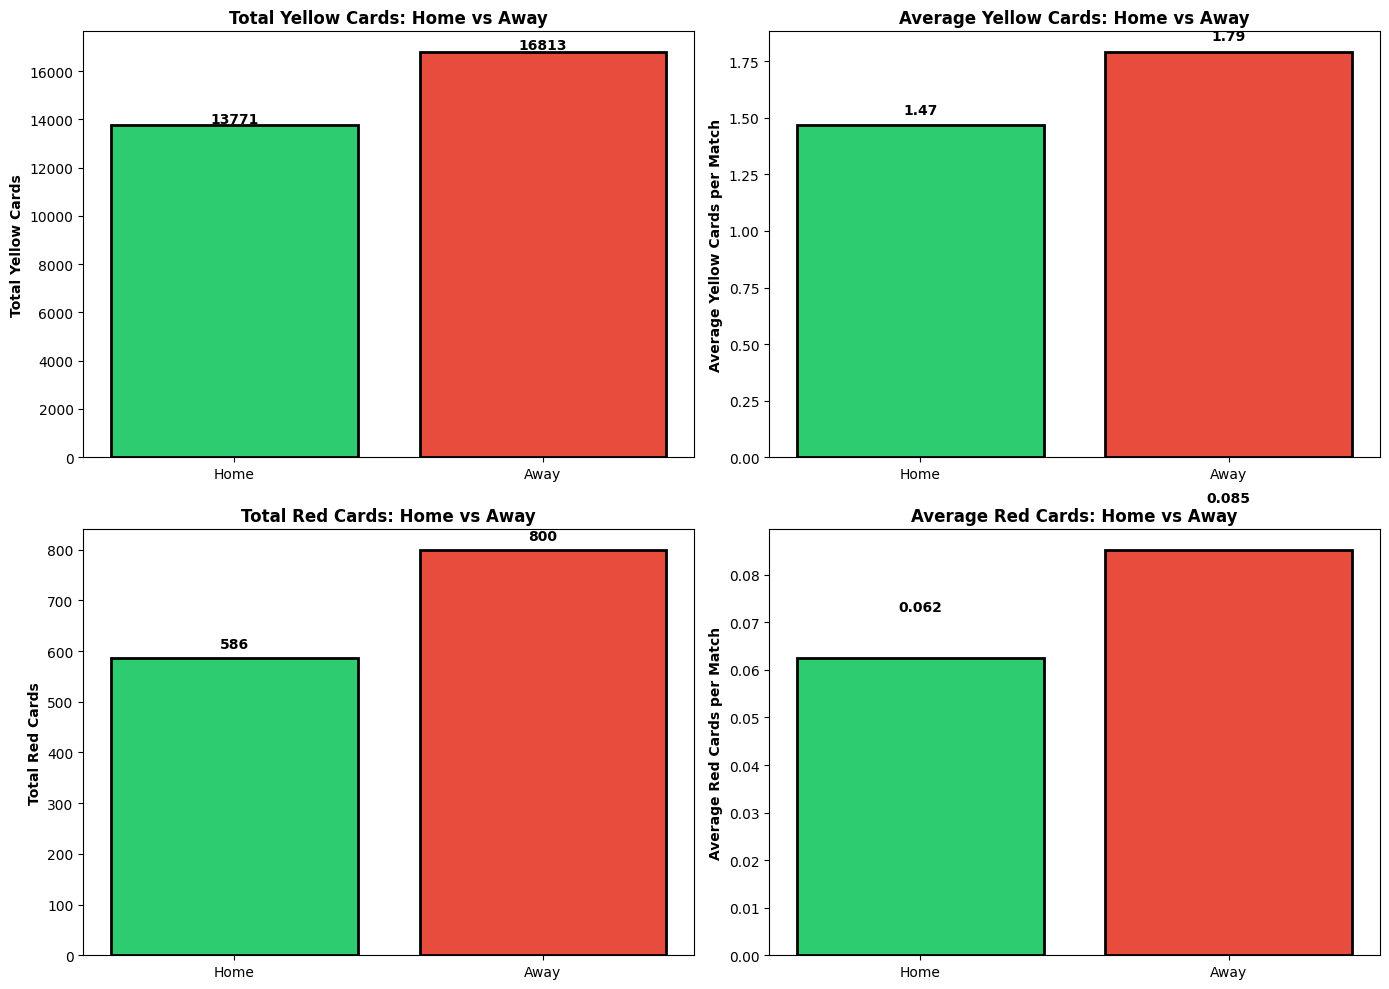

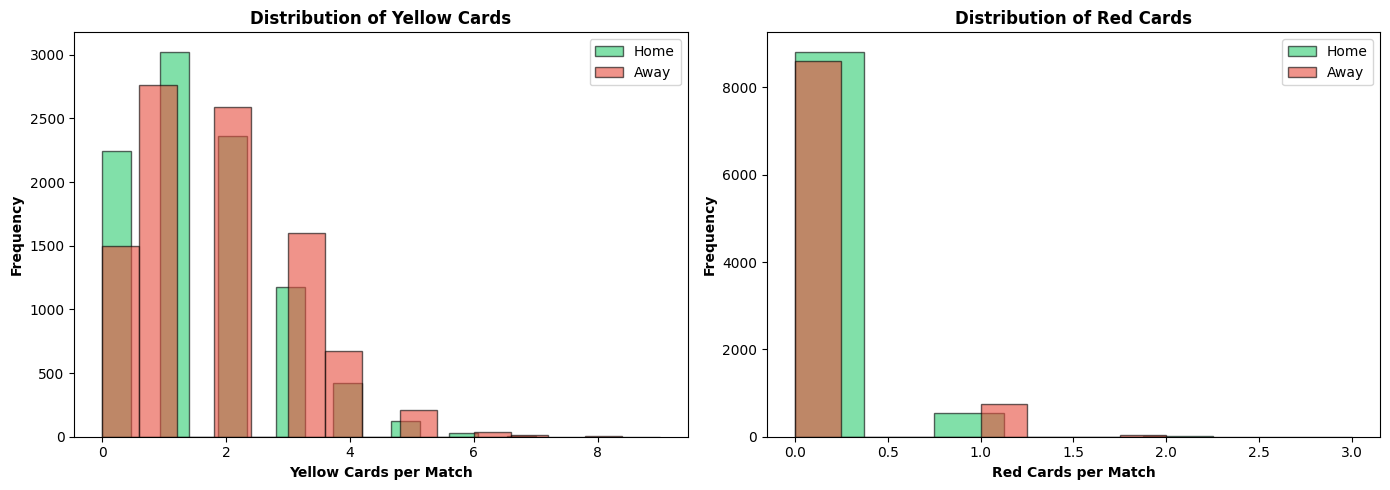

In [25]:
# Yellow and Red Cards Analysis - Home vs Away
print("\n" + "="*80)
print("CARDS ANALYSIS: HOME vs AWAY")
print("="*80)

# Get card columns
home_yellow = df['HomeYellowCards']
away_yellow = df['AwayYellowCards']
home_red = df['HomeRedCards']
away_red = df['AwayRedCards']

total_matches = len(df)

print(f"\n{'='*80}")
print("📊 YELLOW CARDS ANALYSIS")
print(f"{'='*80}")

h_yellow_total = home_yellow.sum()
a_yellow_total = away_yellow.sum()
h_yellow_avg = home_yellow.mean()
a_yellow_avg = away_yellow.mean()

print(f"\n🏠 HOME YELLOW CARDS:")
print(f"   Total: {h_yellow_total:,}")
print(f"   Average per match: {h_yellow_avg:.2f}")
print(f"   Min: {home_yellow.min()}, Max: {home_yellow.max()}")
print(f"   Median: {home_yellow.median():.2f}, Std Dev: {home_yellow.std():.2f}")

print(f"\n✈️  AWAY YELLOW CARDS:")
print(f"   Total: {a_yellow_total:,}")
print(f"   Average per match: {a_yellow_avg:.2f}")
print(f"   Min: {away_yellow.min()}, Max: {away_yellow.max()}")
print(f"   Median: {away_yellow.median():.2f}, Std Dev: {away_yellow.std():.2f}")

print(f"\n⚖️  YELLOW CARDS COMPARISON:")
yellow_diff = h_yellow_avg - a_yellow_avg
print(f"   Home avg - Away avg: {yellow_diff:.4f}")
print(f"   Home receives {'MORE' if yellow_diff > 0 else 'FEWER'} yellow cards on average")
print(f"   Difference: {abs(yellow_diff):.4f} cards per match")

print(f"\n{'='*80}")
print("🔴 RED CARDS ANALYSIS")
print(f"{'='*80}")

h_red_total = home_red.sum()
a_red_total = away_red.sum()
h_red_avg = home_red.mean()
a_red_avg = away_red.mean()

print(f"\n🏠 HOME RED CARDS:")
print(f"   Total: {h_red_total:,}")
print(f"   Average per match: {h_red_avg:.2f}")
print(f"   Min: {home_red.min()}, Max: {home_red.max()}")
print(f"   Median: {home_red.median():.2f}, Std Dev: {home_red.std():.2f}")
print(f"   Matches with red card: {(home_red > 0).sum()} ({(home_red > 0).sum()/total_matches*100:.2f}%)")

print(f"\n✈️  AWAY RED CARDS:")
print(f"   Total: {a_red_total:,}")
print(f"   Average per match: {a_red_avg:.2f}")
print(f"   Min: {away_red.min()}, Max: {away_red.max()}")
print(f"   Median: {away_red.median():.2f}, Std Dev: {away_red.std():.2f}")
print(f"   Matches with red card: {(away_red > 0).sum()} ({(away_red > 0).sum()/total_matches*100:.2f}%)")

print(f"\n⚖️  RED CARDS COMPARISON:")
red_diff = h_red_avg - a_red_avg
print(f"   Home avg - Away avg: {red_diff:.4f}")
print(f"   Home receives {'MORE' if red_diff > 0 else 'FEWER'} red cards on average")
print(f"   Difference: {abs(red_diff):.4f} cards per match")

print(f"\n{'='*80}")
print("📋 SUMMARY COMPARISON")
print(f"{'='*80}")

total_home_cards = h_yellow_total + h_red_total
total_away_cards = a_yellow_total + a_red_total
avg_home_cards = home_yellow.mean() + home_red.mean()
avg_away_cards = away_yellow.mean() + away_red.mean()

print(f"\n🏠 HOME TEAMS - Total Cards:")
print(f"   Yellow + Red = {h_yellow_total:,} + {h_red_total:,} = {total_home_cards:,}")
print(f"   Average per match: {avg_home_cards:.2f}")

print(f"\n✈️  AWAY TEAMS - Total Cards:")
print(f"   Yellow + Red = {a_yellow_total:,} + {a_red_total:,} = {total_away_cards:,}")
print(f"   Average per match: {avg_away_cards:.2f}")

print(f"\n💡 KEY INSIGHT:")
total_diff = avg_home_cards - avg_away_cards
if total_diff > 0:
    print(f"   ⚠️  Home teams receive {total_diff:.2f} MORE cards per match on average")
    print(f"   This could indicate: Home teams play more aggressively OR")
    print(f"   Away teams play more cautiously/defensively")
else:
    print(f"   ⚠️  Away teams receive {abs(total_diff):.2f} MORE cards per match on average")
    print(f"   This could indicate: Away teams need to be more aggressive OR")
    print(f"   Home teams have advantage and can play more conservatively")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Yellow cards comparison
categories = ['Home', 'Away']
yellow_totals = [h_yellow_total, a_yellow_total]
yellow_avgs = [h_yellow_avg, a_yellow_avg]

axes[0, 0].bar(categories, yellow_totals, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Total Yellow Cards', fontweight='bold')
axes[0, 0].set_title('Total Yellow Cards: Home vs Away', fontweight='bold', fontsize=12)
for i, v in enumerate(yellow_totals):
    axes[0, 0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Yellow cards average
axes[0, 1].bar(categories, yellow_avgs, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Average Yellow Cards per Match', fontweight='bold')
axes[0, 1].set_title('Average Yellow Cards: Home vs Away', fontweight='bold', fontsize=12)
for i, v in enumerate(yellow_avgs):
    axes[0, 1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Red cards comparison
red_totals = [h_red_total, a_red_total]
red_avgs = [h_red_avg, a_red_avg]

axes[1, 0].bar(categories, red_totals, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Total Red Cards', fontweight='bold')
axes[1, 0].set_title('Total Red Cards: Home vs Away', fontweight='bold', fontsize=12)
for i, v in enumerate(red_totals):
    axes[1, 0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Red cards average
axes[1, 1].bar(categories, red_avgs, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Average Red Cards per Match', fontweight='bold')
axes[1, 1].set_title('Average Red Cards: Home vs Away', fontweight='bold', fontsize=12)
for i, v in enumerate(red_avgs):
    axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(home_yellow, bins=15, alpha=0.6, label='Home', color='#2ecc71', edgecolor='black')
axes[0].hist(away_yellow, bins=15, alpha=0.6, label='Away', color='#e74c3c', edgecolor='black')
axes[0].set_xlabel('Yellow Cards per Match', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Distribution of Yellow Cards', fontweight='bold', fontsize=12)
axes[0].legend()

axes[1].hist(home_red, bins=8, alpha=0.6, label='Home', color='#2ecc71', edgecolor='black')
axes[1].hist(away_red, bins=8, alpha=0.6, label='Away', color='#e74c3c', edgecolor='black')
axes[1].set_xlabel('Red Cards per Match', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Distribution of Red Cards', fontweight='bold', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()
